# Prédiction personnalisée client — 14 jours d'entrée → 2 jours prédits

Objectif : prédire la courbe de consommation future d'un client

A partir de 14 jours passés du client, on prédit 2 jours futurs du même client

Ce notebook compare les modèles avec :

1. une baseline récente : recopier les 2 derniers jours
2. une baseline hebdomadaire : recopier les mêmes créneaux de la semaine précédente
3. un modèle Ridge qui apprend une correction de la meilleure baseline
4. un CNN 1D résiduel léger qui apprend aussi une correction de baseline.

Le modèle reste volontairement raisonnable pour éviter un temps d'exécution trop long.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

try:
    import holidays
except ImportError:
    class _EmptyFranceHolidays:
        def __contains__(self, date):
            return False

    class holidays:
        @staticmethod
        def France(*args, **kwargs):
            print("Package 'holidays' non installé : is_holiday sera toujours égal à 0.")
            return _EmptyFranceHolidays()

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

print("Librairies chargées")
print(f"PyTorch disponible : {TORCH_AVAILABLE}")
if TORCH_AVAILABLE:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device PyTorch utilisé : {DEVICE}")
    if torch.cuda.is_available():
        print(f"GPU détecté : {torch.cuda.get_device_name(0)}")
else:
    DEVICE = None



Librairies chargées
PyTorch disponible : True
Device PyTorch utilisé : cpu


In [ ]:
# ──────────────────────────────────────────────────────────────────
# PARAMÈTRES
# ──────────────────────────────────────────────────────────────────
#  Chemins 
BASE_DIR    = Path.cwd().parent
FILE_PATH   = "/content/RES2-6-9.csv"
LABELS_PATH = "/content/RES2-6-9-labels.csv"

# Séquences
INPUT_LEN = 672        # 14 jours passés × 48 demi-heures
HORIZON   = 96         # 2 jours futurs × 48 demi-heures
STRIDE    = 48         # un point de départ par jour et par client

# Le modèle utilise des informations hebdomadaires jusqu'à 14 jours dans le passé.
MIN_HISTORY_FOR_FEATURES = INPUT_LEN

# Découpage par clients
# Les clients du train, de la validation et du test sont disjoints.
# Cela permet de tester la généralisation à des clients jamais vus pendant l'entraînement.
VAL_CLIENT_FRAC  = 0.15
TEST_CLIENT_FRAC = 0.15

# Modèles
RIDGE_ALPHAS = [1.0, 10.0, 100.0, 300.0]
SELECTION_METRIC = "WMAPE"

# Seuil utilisé pour construire les indicateurs d'activité passée
# Un jour passé est considéré actif si son énergie journalière dépasse ce seuil.
ACTIVE_DAY_KWH = 1.0

# CNN léger pour rester sous un temps de calcul raisonnable
RUN_CNN = True
CNN_EPOCHS = 8
CNN_BATCH_SIZE = 512
CNN_LR = 1e-3
CNN_WEIGHT_DECAY = 1e-4
MAX_TRAIN_SAMPLES_CNN = 60000
MAX_VAL_SAMPLES_CNN = 20000
RANDOM_STATE = 42

# Pour accélérer les essais, mettre par exemple 50.
# Pour le rendu final, laisser None.
MAX_CLIENTS_PER_SEGMENT = None

np.random.seed(RANDOM_STATE)
if TORCH_AVAILABLE:
    torch.manual_seed(RANDOM_STATE)

print(f"Entrée : {INPUT_LEN} demi-heures = {INPUT_LEN // 48} jours")
print(f"Sortie : {HORIZON} demi-heures = {HORIZON // 48} jours")
print(f"Stride : {STRIDE} demi-heures = {STRIDE // 48} jour")
print(f"Split clients : validation={VAL_CLIENT_FRAC:.0%} | test={TEST_CLIENT_FRAC:.0%}")



Entrée : 672 demi-heures = 14 jours
Sortie : 96 demi-heures = 2 jours
Stride : 48 demi-heures = 1 jour
Split clients : validation=15% | test=15%


## 1. Chargement des données
Le projet utilise deux fichiers principaux :

- RES2-6-9.csv

- RES2-6-9-labels.csv

Le fichier de consommation contient les courbes de charge au pas de 30 minutes.
Après chargement, les colonnes utilisées sont :

- pdl_id : identifiant du client / point de livraison

- horodate : date et heure de la mesure

- puissance_w : puissance appelée en watts

Le fichier de labels contient les classes de clients :
- pdl_id
- label_rs_rp
- cluster_ref

La convention utilisée est :

- 1 = RS : résidence secondaire

- 0 = RP : résidence principale

In [3]:
# ── Étiquettes RS / RP ────────────────────────────────────────────
ref = pd.read_csv(LABELS_PATH)
ref.columns = ["pdl_id", "label_rs_rp", "cluster_ref"]

# Convention du fichier labels : 0 = RS, 1 = RP
ref["segment"] = np.where(ref["label_rs_rp"] == 0, "RP", "RS")

print("Répartition des clients dans les labels :")
print(ref["segment"].value_counts())

# ── Données brutes ────────────────────────────────────────────────
raw = pd.read_csv(FILE_PATH)
raw.columns = ["pdl_id", "horodate", "puissance_w"]

raw["horodate"] = pd.to_datetime(raw["horodate"], utc=True, errors="coerce")
raw["puissance_w"] = pd.to_numeric(raw["puissance_w"], errors="coerce")
raw = raw.dropna(subset=["pdl_id", "horodate", "puissance_w"])

# Ajout du segment RS/RP ; on ne garde que les PDL labellisés.
raw = raw.merge(ref[["pdl_id", "label_rs_rp", "segment"]], on="pdl_id", how="inner")

# Conversion W au pas 30 min → kWh sur 30 min
raw["kwh"] = raw["puissance_w"] * 0.5 / 1000

# Tri par client et par date
raw = raw.sort_values(["pdl_id", "horodate"]).reset_index(drop=True)

# Option pour réduire le nombre de clients pendant les essais
if MAX_CLIENTS_PER_SEGMENT is not None:
    keep_pdls = []
    for seg in ["RS", "RP"]:
        pdls_seg = raw.loc[raw["segment"] == seg, "pdl_id"].drop_duplicates()
        keep_pdls.extend(pdls_seg.head(MAX_CLIENTS_PER_SEGMENT).tolist())
    raw = raw[raw["pdl_id"].isin(keep_pdls)].copy()

print(f"Lignes : {len(raw):,}")
print(f"Période : {raw['horodate'].min()} → {raw['horodate'].max()}")
print(f"Clients : {raw['pdl_id'].nunique()}")
print("Répartition des lignes :")
print(raw["segment"].value_counts())

display(raw.head())


Répartition des clients dans les labels :
segment
RP    428
RS     72
Name: count, dtype: int64
Lignes : 8,736,000
Période : 2023-10-31 23:00:00+00:00 → 2024-10-29 22:30:00+00:00
Clients : 500
Répartition des lignes :
segment
RP    7478016
RS    1257984
Name: count, dtype: int64


,pdl_id,horodate,puissance_w,label_rs_rp,segment,kwh
0,1704875583,2023-10-31 23:00:00+00:00,308.8,0,RP,0.15440
1,1704875583,2023-10-31 23:30:00+00:00,330.4,0,RP,0.16520
2,1704875583,2023-11-01 00:00:00+00:00,299.0,0,RP,0.14950
3,1704875583,2023-11-01 00:30:00+00:00,245.7,0,RP,0.12285
4,1704875583,2023-11-01 01:00:00+00:00,258.9,0,RP,0.12945


## 2. Fonctions de métriques et features

### 2.1 Métriques utilisées

On calcule les métriques suivantes :
- MAE
- RMSE
- WMAPE
- MAPE filtré
- sMAPE

### 2.2 Features

En ce qui concerne les features, pour chaque exemple, le modèle utilise deux types d’informations :

X_tab = [X_seq, X_extra]

avec :

- X_seq : courbe brute des 14 jours passés

- X_extra : variables explicatives supplémentaires

X_extra contient des variables calendaires, des lags individuels, des statistiques sur l'historique et des variables d'activité passé.

Pour plus d'informations, regarder le README

In [4]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 1e-8
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def wmape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    if denom <= 1e-8:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom * 100


def mape_raw(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.where(np.abs(y_true) <= 1e-8, np.nan, y_true)
    return np.nanmean(np.abs((y_true - y_pred) / denom)) * 100


def filtered_mape(y_true, y_pred, threshold=0.10):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true > threshold
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def regression_metrics(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    out = {
        prefix + "MAE": mean_absolute_error(y_true, y_pred),
        prefix + "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        prefix + "WMAPE": wmape(y_true, y_pred),
        prefix + "sMAPE": smape(y_true, y_pred),
        prefix + "MAPE_brut": mape_raw(y_true, y_pred),
        prefix + "MAPE_filtre_010": filtered_mape(y_true, y_pred, threshold=0.10),
    }
    return out


def print_metrics(title, metrics):
    print("=" * 70)
    print(title)
    print("=" * 70)
    for k, v in metrics.items():
        if isinstance(v, (float, np.floating)):
            if "MAPE" in k or "WMAPE" in k or "sMAPE" in k:
                print(f"{k:18s}: {v:8.2f} %")
            else:
                print(f"{k:18s}: {v:8.4f}")
        else:
            print(f"{k:18s}: {v}")


In [5]:
# Jours fériés France, avec fallback si le package holidays n'est pas installé
annees = sorted(raw["horodate"].dt.year.unique())
fr_holidays = holidays.France(years=annees)


def is_school_holiday_proxy(dt):
    """Proxy simple : mois de vacances fréquentes en France."""
    m = dt.month
    return int(m in [7, 8, 12])


def season_from_month(m):
    if m in [12, 1, 2]:
        return 0  # hiver
    if m in [3, 4, 5]:
        return 1  # printemps
    if m in [6, 7, 8]:
        return 2  # été
    return 3      # automne


def longest_run_bool(values):
    best = 0
    cur = 0
    for v in values:
        if v:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return best


def build_extra_features(past_seq, anchor_time, segment):
    """Features disponibles au moment de la prédiction.
    past_seq : 14 jours passés, longueur INPUT_LEN.
    anchor_time : dernier horodatage observé.
    segment : 'RS' ou 'RP'.
    """
    past_seq = np.asarray(past_seq, dtype=np.float32)
    forecast_start = anchor_time + pd.Timedelta(minutes=30)
    dow = forecast_start.weekday()
    month = forecast_start.month
    season = season_from_month(month)

    last_1d = past_seq[-48:]
    last_2d = past_seq[-96:]
    last_7d = past_seq[-336:]
    last_14d = past_seq[-672:]

    # Activité passée au pas 30 min et au niveau jour
    active_30 = past_seq > 0.02
    daily_energy_14 = last_14d.reshape(-1, 48).sum(axis=1)
    active_days_14 = daily_energy_14 > ACTIVE_DAY_KWH
    daily_energy_7 = last_7d.reshape(-1, 48).sum(axis=1)
    active_days_7 = daily_energy_7 > ACTIVE_DAY_KWH

    # Week-end / semaine sur les 14 jours passés.
    # On reconstruit les jours passés à partir de forecast_start.
    past_day_dates = [forecast_start.normalize() - pd.Timedelta(days=d) for d in range(14, 0, -1)]
    is_weekend_past = np.array([d.weekday() >= 5 for d in past_day_dates])

    weekday_energy = daily_energy_14[~is_weekend_past].sum() if (~is_weekend_past).any() else 0.0
    weekend_energy = daily_energy_14[is_weekend_past].sum() if is_weekend_past.any() else 0.0

    eps = 1e-6
    feats = []

    # Calendrier du début de prévision
    feats.extend([
        np.sin(2 * np.pi * dow / 7),
        np.cos(2 * np.pi * dow / 7),
        float(dow >= 5),
        np.sin(2 * np.pi * month / 12),
        np.cos(2 * np.pi * month / 12),
        float(forecast_start.date() in fr_holidays),
        float(is_school_holiday_proxy(forecast_start)),
    ])
    feats.extend([float(season == s) for s in range(4)])
    feats.extend([float(segment == "RS"), float(segment == "RP")])

    # Lags individuels inspirés du hackathon
    feats.extend([
        past_seq[-1],
        past_seq[-48],
        past_seq[-96],
        past_seq[-336],
        past_seq[-672],
    ])

    # Statistiques mobiles sur 1, 2, 7 et 14 jours
    for arr in [last_1d, last_2d, last_7d, last_14d]:
        feats.extend([
            arr.mean(),
            arr.std(),
            arr.min(),
            arr.max(),
            arr.sum(),
        ])

    # Activité passée
    feats.extend([
        active_30[-48:].mean(),
        active_30[-96:].mean(),
        active_30[-336:].mean(),
        active_30[-672:].mean(),
        active_days_7.mean(),
        active_days_14.mean(),
        active_days_7.sum(),
        active_days_14.sum(),
        longest_run_bool(active_days_14),
        daily_energy_7.mean(),
        daily_energy_7.std(),
        daily_energy_14.mean(),
        daily_energy_14.std(),
        weekend_energy,
        weekday_energy,
        weekend_energy / (weekday_energy + eps),
    ])

    # Comparaisons de niveaux récents
    feats.extend([
        last_7d.mean() / (last_14d.mean() + eps),
        last_2d.mean() / (last_7d.mean() + eps),
        last_1d.mean() / (last_7d.mean() + eps),
        last_7d.mean() - last_14d.mean(),
        last_2d.mean() - last_7d.mean(),
        last_1d.mean() - last_7d.mean(),
    ])

    return np.asarray(feats, dtype=np.float32)


EXTRA_FEATURE_NAMES = [
    "dow_sin", "dow_cos", "is_weekend_start", "month_sin", "month_cos",
    "is_holiday_start", "is_school_holiday_proxy",
    "season_winter", "season_spring", "season_summer", "season_autumn",
    "is_RS", "is_RP",
    "lag_1", "lag_48", "lag_96", "lag_336", "lag_672",
]
for w_name in ["1d", "2d", "7d", "14d"]:
    EXTRA_FEATURE_NAMES += [f"mean_{w_name}", f"std_{w_name}", f"min_{w_name}", f"max_{w_name}", f"sum_{w_name}"]
EXTRA_FEATURE_NAMES += [
    "active_rate_1d", "active_rate_2d", "active_rate_7d", "active_rate_14d",
    "active_days_rate_7d", "active_days_rate_14d", "active_days_count_7d", "active_days_count_14d",
    "longest_active_run_14d", "daily_energy_7d_mean", "daily_energy_7d_std",
    "daily_energy_14d_mean", "daily_energy_14d_std", "weekend_energy_14d", "weekday_energy_14d",
    "weekend_over_weekday_energy", "ratio_mean_7d_14d", "ratio_mean_2d_7d", "ratio_mean_1d_7d",
    "diff_mean_7d_14d", "diff_mean_2d_7d", "diff_mean_1d_7d",
]
print(f"Nombre de features extra : {len(EXTRA_FEATURE_NAMES)}")


Nombre de features extra : 60


## 3. Construction des fenêtres client par client

Chaque exemple est construit ainsi :

```text
X_seq    = 14 jours passés du client, 672 valeurs
X_extra  = tous les autres features
Y        = 2 jours futurs du même client, 96 valeurs
```

Pour chaque client, le programme construit des fenêtres temporelles glissantes.

Le paramètre utilisé est STRIDE = 48

In [6]:
def build_windows_for_client(g):
    g = g.sort_values("horodate")
    values = g["kwh"].to_numpy(dtype=np.float32)
    times = g["horodate"].to_numpy()
    pdl = g["pdl_id"].iloc[0]
    segment = g["segment"].iloc[0]

    n = len(g)
    rows = []
    max_start = n - INPUT_LEN - HORIZON
    if max_start < 0:
        return rows

    for start in range(0, max_start + 1, STRIDE):
        input_end = start + INPUT_LEN
        target_end = input_end + HORIZON

        past_seq = values[start:input_end]
        future_seq = values[input_end:target_end]
        anchor_time = pd.Timestamp(times[input_end - 1])
        forecast_start = anchor_time + pd.Timedelta(minutes=30)

        # Baseline récente : on recopie les 2 derniers jours observés
        baseline_recent = past_seq[-HORIZON:]

        # Baseline hebdomadaire : mêmes créneaux de la semaine précédente
        weekly_start = INPUT_LEN - 336
        weekly_end = weekly_start + HORIZON
        baseline_weekly = past_seq[weekly_start:weekly_end]

        extra = build_extra_features(past_seq, anchor_time, segment)

        rows.append({
            "pdl_id": pdl,
            "segment": segment,
            "anchor_time": anchor_time,
            "forecast_start": forecast_start,
            "X_seq": past_seq,
            "X_extra": extra,
            "Y": future_seq,
            "baseline_recent": baseline_recent,
            "baseline_weekly": baseline_weekly,
        })

    return rows


all_rows = []
for i, (_, g) in enumerate(raw.groupby("pdl_id"), start=1):
    all_rows.extend(build_windows_for_client(g))
    if i % 100 == 0:
        print(f"Clients traités : {i}")

windows = pd.DataFrame(all_rows)
print(f"Nombre total de fenêtres : {len(windows):,}")
print("Fenêtres par segment :")
print(windows["segment"].value_counts())
print(f"Période des départs de prévision : {windows['forecast_start'].min()} → {windows['forecast_start'].max()}")

display(windows.head())



Clients traités : 100
Clients traités : 200
Clients traités : 300
Clients traités : 400
Clients traités : 500
Nombre total de fenêtres : 174,500
Fenêtres par segment :
segment
RP    149372
RS     25128
Name: count, dtype: int64
Période des départs de prévision : 2023-11-14 23:00:00+00:00 → 2024-10-27 23:00:00+00:00


,pdl_id,segment,anchor_time,forecast_start,X_seq,X_extra,Y,baseline_recent,baseline_weekly
0,1704875583,RP,2023-11-14 22:30:00+00:00,2023-11-14 23:00:00+00:00,"[0.1544, 0.1652, 0.1495, 0.12285, 0.12945, 0.1...","[0.7818315, 0.6234898, 0.0, -0.5, 0.8660254, 0...","[0.31785, 0.29115, 0.214, 0.1949, 0.29905, 0.6...","[0.23965, 0.2425, 0.17455, 0.21485, 0.1685, 0....","[0.234, 0.179, 0.2162, 0.22185, 0.2208, 0.231,..."
1,1704875583,RP,2023-11-15 22:30:00+00:00,2023-11-15 23:00:00+00:00,"[0.1543, 0.1788, 0.17145, 0.14245, 0.15415, 0....","[0.9749279, -0.22252093, 0.0, -0.5, 0.8660254,...","[0.22965, 0.07765, 0.0556, 0.2082, 0.1273, 0.2...","[0.18825, 0.16735, 0.08705, 0.05375, 0.1145, 0...","[0.21545, 0.1786, 0.1614, 0.154, 0.1804, 0.192..."
2,1704875583,RP,2023-11-16 22:30:00+00:00,2023-11-16 23:00:00+00:00,"[0.18945, 0.2, 0.25435, 0.1895, 0.1799, 0.6890...","[0.43388373, -0.90096885, 0.0, -0.5, 0.8660254...","[0.29805, 0.2242, 0.16245, 0.20535, 0.1769, 0....","[0.31785, 0.29115, 0.214, 0.1949, 0.29905, 0.6...","[0.20965, 0.20825, 0.14525, 0.1938, 0.1855, 0...."
3,1704875583,RP,2023-11-17 22:30:00+00:00,2023-11-17 23:00:00+00:00,"[0.19875, 0.16465, 0.193, 0.15725, 0.20135, 0....","[-0.43388373, -0.90096885, 0.0, -0.5, 0.866025...","[0.15115, 0.25135, 0.2772, 0.2716, 0.23035, 0....","[0.22965, 0.07765, 0.0556, 0.2082, 0.1273, 0.2...","[0.19135, 0.23525, 0.30305, 0.2082, 0.2744, 0...."
4,1704875583,RP,2023-11-18 22:30:00+00:00,2023-11-18 23:00:00+00:00,"[0.1694, 0.14415, 0.1348, 0.1251, 0.1393, 0.14...","[-0.9749279, -0.22252093, 1.0, -0.5, 0.8660254...","[0.28125, 0.254, 0.29395, 0.29995, 0.3331, 0.4...","[0.29805, 0.2242, 0.16245, 0.20535, 0.1769, 0....","[0.22835, 0.11285, 0.0976, 0.23035, 0.15805, 0..."


In [7]:
# Conversion en matrices numpy
X_seq = np.stack(windows["X_seq"].values).astype(np.float32)
X_extra = np.stack(windows["X_extra"].values).astype(np.float32)
Y = np.stack(windows["Y"].values).astype(np.float32)
B_recent = np.stack(windows["baseline_recent"].values).astype(np.float32)
B_weekly = np.stack(windows["baseline_weekly"].values).astype(np.float32)
pdl_ids = windows["pdl_id"].values
segments = windows["segment"].values
forecast_starts = pd.to_datetime(windows["forecast_start"])

print(f"X_seq    : {X_seq.shape}")
print(f"X_extra  : {X_extra.shape}")
print(f"Y        : {Y.shape}")
print(f"B_recent : {B_recent.shape}")
print(f"B_weekly : {B_weekly.shape}")



X_seq    : (174500, 672)
X_extra  : (174500, 60)
Y        : (174500, 96)
B_recent : (174500, 96)
B_weekly : (174500, 96)


## 4. Séparation par clients train / validation / test

Le découpage se fait au niveau des clients (`pdl_id`), et non plus uniquement par date.

L'objectif est de tester la capacité du modèle à généraliser à des clients jamais vus pendant l'entraînement :

```text
clients train | clients validation | clients test
```

Les ensembles sont disjoints : un client présent dans le test n'apparaît jamais dans le train ni dans la validation.

La séparation est stratifiée par segment RP / RS afin de conserver des proportions proches dans les trois ensembles.


In [8]:
# ──────────────────────────────────────────────────────────────────
# SÉPARATION PAR CLIENTS
# ──────────────────────────────────────────────────────────────────
# On sépare les pdl_id, puis on récupère toutes les fenêtres associées
# aux clients du train, de la validation et du test.
#
# Ce protocole teste la généralisation à des clients jamais vus pendant
# l'entraînement. Il est donc plus strict qu'un simple split temporel.
# ──────────────────────────────────────────────────────────────────

client_meta = (
    windows[["pdl_id", "segment"]]
    .drop_duplicates("pdl_id")
    .reset_index(drop=True)
)

rng = np.random.default_rng(RANDOM_STATE)

train_clients = []
val_clients = []
test_clients = []

for seg, df_seg in client_meta.groupby("segment"):
    clients_seg = df_seg["pdl_id"].to_numpy()
    rng.shuffle(clients_seg)

    n_clients = len(clients_seg)
    n_test = max(1, int(round(TEST_CLIENT_FRAC * n_clients)))
    n_val = max(1, int(round(VAL_CLIENT_FRAC * n_clients)))

    test_seg = clients_seg[:n_test]
    val_seg = clients_seg[n_test:n_test + n_val]
    train_seg = clients_seg[n_test + n_val:]

    test_clients.extend(test_seg)
    val_clients.extend(val_seg)
    train_clients.extend(train_seg)

train_clients = np.array(train_clients)
val_clients = np.array(val_clients)
test_clients = np.array(test_clients)

train_client_set = set(train_clients)
val_client_set = set(val_clients)
test_client_set = set(test_clients)

idx_train = np.where(np.isin(pdl_ids, train_clients))[0]
idx_val = np.where(np.isin(pdl_ids, val_clients))[0]
idx_test = np.where(np.isin(pdl_ids, test_clients))[0]

print("=" * 70)
print("SÉPARATION PAR CLIENTS")
print("=" * 70)
print(f"Clients train : {len(train_clients):,}")
print(f"Clients val   : {len(val_clients):,}")
print(f"Clients test  : {len(test_clients):,}")
print()
print(f"Fenêtres train : {len(idx_train):,}")
print(f"Fenêtres val   : {len(idx_val):,}")
print(f"Fenêtres test  : {len(idx_test):,}")

# Vérification : aucun client ne doit apparaître dans plusieurs ensembles
overlap_train_val = train_client_set & val_client_set
overlap_train_test = train_client_set & test_client_set
overlap_val_test = val_client_set & test_client_set

print("\nVérification des chevauchements de clients :")
print(f"Train ∩ Val  : {len(overlap_train_val)}")
print(f"Train ∩ Test : {len(overlap_train_test)}")
print(f"Val ∩ Test   : {len(overlap_val_test)}")

if len(overlap_train_val) == 0 and len(overlap_train_test) == 0 and len(overlap_val_test) == 0:
    print("OK : aucun client n'est partagé entre train, validation et test.")
else:
    print("Attention : certains clients apparaissent dans plusieurs ensembles.")

# Répartition RP / RS par ensemble
split_client_summary = pd.concat([
    client_meta[client_meta["pdl_id"].isin(train_clients)].assign(split="train"),
    client_meta[client_meta["pdl_id"].isin(val_clients)].assign(split="validation"),
    client_meta[client_meta["pdl_id"].isin(test_clients)].assign(split="test"),
], ignore_index=True)

print("\nRépartition des clients par segment :")
display(pd.crosstab(split_client_summary["split"], split_client_summary["segment"]))

print("\nRépartition des fenêtres par segment :")
windows_split_summary = pd.DataFrame({
    "split": np.where(
        np.isin(pdl_ids, train_clients), "train",
        np.where(np.isin(pdl_ids, val_clients), "validation", "test")
    ),
    "segment": segments,
})
display(pd.crosstab(windows_split_summary["split"], windows_split_summary["segment"]))

print("\nPériodes couvertes par chaque split :")
for name, idx_split in [("train", idx_train), ("validation", idx_val), ("test", idx_test)]:
    print(
        f"{name:10s} : "
        f"{forecast_starts.iloc[idx_split].min()} → {forecast_starts.iloc[idx_split].max()}"
    )


SÉPARATION PAR CLIENTS
Clients train : 350
Clients val   : 75
Clients test  : 75

Fenêtres train : 122,150
Fenêtres val   : 26,175
Fenêtres test  : 26,175

Vérification des chevauchements de clients :
Train ∩ Val  : 0
Train ∩ Test : 0
Val ∩ Test   : 0
OK : aucun client n'est partagé entre train, validation et test.

Répartition des clients par segment :


segment,RP,RS
split,,
test,64,11
train,300,50
validation,64,11



Répartition des fenêtres par segment :


segment,RP,RS
split,,
test,22336,3839
train,104700,17450
validation,22336,3839



Périodes couvertes par chaque split :
train      : 2023-11-14 23:00:00+00:00 → 2024-10-27 23:00:00+00:00
validation : 2023-11-14 23:00:00+00:00 → 2024-10-27 23:00:00+00:00
test       : 2023-11-14 23:00:00+00:00 → 2024-10-27 23:00:00+00:00


## 5. Baselines

On compare d'abord deux méthodes simples, client par client :

- `recent` : recopier les 2 derniers jours ;
- `weekly` : recopier les mêmes créneaux de la semaine précédente.

La meilleure baseline en validation sera utilisée comme base résiduelle pour Ridge et CNN.

In [9]:
def evaluate_prediction_by_segment(y_true, y_pred, idx, name):
    """Évalue une prédiction par segment.

    Cette fonction accepte deux formats de y_pred :
    - prédiction complète de taille len(Y), par exemple B_recent ou B_weekly ;
    - prédiction locale de taille len(idx), par exemple les prédictions validation/test
      calculées uniquement sur idx_val ou idx_test.

    Cela évite les erreurs du type :
    IndexError: index ... is out of bounds for axis 0 with size len(idx)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    idx = np.asarray(idx, dtype=int)

    rows = []
    local_positions = np.arange(len(idx))

    for seg in ["RS", "RP", "ALL"]:
        if seg == "ALL":
            global_idx = idx
            local_idx = local_positions
        else:
            seg_mask = segments[idx] == seg
            global_idx = idx[seg_mask]
            local_idx = local_positions[seg_mask]

        if len(global_idx) == 0:
            continue

        # y_true est normalement complet, mais on garde une gestion robuste.
        if y_true.shape[0] == len(idx):
            yt = y_true[local_idx]
        else:
            yt = y_true[global_idx]

        # Cas 1 : y_pred contient toutes les lignes du dataset.
        if y_pred.shape[0] == len(segments):
            yp = y_pred[global_idx]
        # Cas 2 : y_pred contient uniquement les prédictions pour idx.
        elif y_pred.shape[0] == len(idx):
            yp = y_pred[local_idx]
        else:
            raise ValueError(
                "Taille incompatible pour y_pred : "
                f"{y_pred.shape[0]} lignes, alors que len(idx)={len(idx)} "
                f"et len(segments)={len(segments)}."
            )

        m = regression_metrics(yt, yp)
        m["segment"] = seg
        m["modele"] = name
        m["n_examples"] = len(global_idx)
        rows.append(m)

    return pd.DataFrame(rows)


baseline_val_recent = evaluate_prediction_by_segment(Y, B_recent, idx_val, "baseline_recent")
baseline_val_weekly = evaluate_prediction_by_segment(Y, B_weekly, idx_val, "baseline_weekly")
baseline_val = pd.concat([baseline_val_recent, baseline_val_weekly], ignore_index=True)

print("Résultats validation — baselines")
display(baseline_val[["modele", "segment", "n_examples", "MAE", "RMSE", "WMAPE", "MAPE_filtre_010", "sMAPE"]])

# Choix de la baseline par segment selon WMAPE validation
baseline_choice = {}
for seg in ["RS", "RP", "ALL"]:
    df_seg = baseline_val[baseline_val["segment"] == seg].sort_values(SELECTION_METRIC)
    if len(df_seg) > 0:
        baseline_choice[seg] = df_seg.iloc[0]["modele"]

print("Choix de baseline selon la validation :")
for seg, choice in baseline_choice.items():
    print(f"  {seg} : {choice}")

# Pour entraîner un modèle global simple, on choisit la meilleure baseline ALL.
BASELINE_MODEL = baseline_choice.get("ALL", "baseline_weekly")
print(f"\nBaseline utilisée pour les modèles résiduels : {BASELINE_MODEL}")

B_base = B_recent if BASELINE_MODEL == "baseline_recent" else B_weekly



Résultats validation — baselines


,modele,segment,n_examples,MAE,RMSE,WMAPE,MAPE_filtre_010,sMAPE
0,baseline_recent,RS,3839,0.170776,0.340787,65.389366,70.082062,68.761047
1,baseline_recent,RP,22336,0.188057,0.343347,55.402573,63.303940,60.432964
2,baseline_recent,ALL,26175,0.185523,0.342972,56.569004,64.117470,61.599453
3,baseline_weekly,RS,3839,0.204552,0.385461,78.321945,83.195801,79.829041
4,baseline_weekly,RP,22336,0.222287,0.385560,65.486717,75.266037,68.897614
5,baseline_weekly,ALL,26175,0.219686,0.385545,66.985832,76.217789,70.440567


Choix de baseline selon la validation :
  RS : baseline_recent
  RP : baseline_recent
  ALL : baseline_recent

Baseline utilisée pour les modèles résiduels : baseline_recent


## 6. Ridge résiduel
Le modèle Ridge ne prédit pas directement la courbe future.  
Il apprend une correction à appliquer à la baseline récente.  

On définit :  
résidu = vraie courbe future − baseline  

Puis le modèle apprend à prédire ce résidu. La prédiction finale est donc :  
bY = Ybaseline + bR  
avec bR le résidu prédit par le modèle Ridge.

In [10]:
# Matrice de features tabulaires : séquence brute + features extra
X_tab = np.hstack([X_seq, X_extra]).astype(np.float32)
Y_residual = (Y - B_base).astype(np.float32)

print(f"X_tab      : {X_tab.shape}")
print(f"Y_residual : {Y_residual.shape}")


X_tab      : (174500, 732)
Y_residual : (174500, 96)


In [11]:
# Sélection de alpha Ridge sur validation
ridge_results = []
ridge_models = {}

for alpha in RIDGE_ALPHAS:
    print(f"Entraînement Ridge alpha={alpha}")
    model = make_pipeline(
        StandardScaler(with_mean=True),
        Ridge(alpha=alpha)
    )
    model.fit(X_tab[idx_train], Y_residual[idx_train])
    ridge_models[alpha] = model

    pred_res_val = model.predict(X_tab[idx_val]).astype(np.float32)
    pred_val = np.clip(B_base[idx_val] + pred_res_val, 0, None)
    metrics_val = regression_metrics(Y[idx_val], pred_val)
    metrics_val["alpha"] = alpha
    ridge_results.append(metrics_val)

ridge_results = pd.DataFrame(ridge_results).sort_values(SELECTION_METRIC).reset_index(drop=True)
print("Résultats validation — Ridge résiduel")
display(ridge_results)

best_alpha = float(ridge_results.iloc[0]["alpha"])
ridge_model = ridge_models[best_alpha]
print(f"Meilleur alpha Ridge selon {SELECTION_METRIC} : {best_alpha}")


Entraînement Ridge alpha=1.0
Entraînement Ridge alpha=10.0
Entraînement Ridge alpha=100.0
Entraînement Ridge alpha=300.0
Résultats validation — Ridge résiduel


,MAE,RMSE,WMAPE,sMAPE,MAPE_brut,MAPE_filtre_010,alpha
0,0.158791,0.261653,48.417980,63.297756,1225.291748,51.057869,300.0
1,0.158823,0.261656,48.427765,63.335472,1225.799438,51.072777,100.0
2,0.158839,0.261660,48.432751,63.354408,1226.047974,51.080177,10.0
3,0.158841,0.261660,48.433273,63.356228,1226.073853,51.080940,1.0


Meilleur alpha Ridge selon WMAPE : 300.0


In [12]:
# Évaluation Ridge sur validation
pred_res_val = ridge_model.predict(X_tab[idx_val]).astype(np.float32)
pred_ridge_val = np.clip(B_base[idx_val] + pred_res_val, 0, None)

ridge_val_table = evaluate_prediction_by_segment(
    Y,
    pred_ridge_val,
    idx_val,
    "ridge_residual"
)

print("Résultats validation — Ridge résiduel")
display(
    ridge_val_table[
        ["modele", "segment", "n_examples", "MAE", "RMSE", "WMAPE", "MAPE_filtre_010", "sMAPE"]
    ]
)




Résultats validation — Ridge résiduel


,modele,segment,n_examples,MAE,RMSE,WMAPE,MAPE_filtre_010,sMAPE
0,ridge_residual,RS,3839,0.147933,0.259830,56.642872,55.450142,77.349808
1,ridge_residual,RP,22336,0.160657,0.261965,47.330296,50.458794,60.932724
2,ridge_residual,ALL,26175,0.158791,0.261653,48.417980,51.057869,63.297756


## 7. CNN 1D résiduel léger

Le CNN reçoit :

- la séquence des 14 jours passés ;
- les features extra individuelles.

Il apprend une correction de baseline comme Ridge :

```text
Y_pred = baseline + correction_CNN
```

Le modèle est volontairement léger, avec sous-échantillonnage du train pour limiter le temps de calcul.

In [13]:
if not TORCH_AVAILABLE:
    print("PyTorch n'est pas disponible : la partie CNN est ignorée.")
    RUN_CNN = False

class SequenceDataset(Dataset):
    def __init__(self, idx, x_seq, x_extra, y_res):
        self.idx = np.asarray(idx)
        self.x_seq = x_seq
        self.x_extra = x_extra
        self.y_res = y_res

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        return (
            torch.from_numpy(self.x_seq[j]),
            torch.from_numpy(self.x_extra[j]),
            torch.from_numpy(self.y_res[j]),
        )

class ResidualCNN1D(nn.Module):
    def __init__(self, n_extra, output_len):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(32),
            nn.Flatten(),
        )
        cnn_dim = 64 * 32
        self.head = nn.Sequential(
            nn.Linear(cnn_dim + n_extra, 256),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(256, output_len),
        )

    def forward(self, x_seq, x_extra):
        x = x_seq.unsqueeze(1)
        h = self.cnn(x)
        z = torch.cat([h, x_extra], dim=1)
        return self.head(z)

print("Classes CNN prêtes")


Classes CNN prêtes


In [14]:
def sample_indices(idx, max_samples, seed=RANDOM_STATE):
    idx = np.asarray(idx)
    if max_samples is None or len(idx) <= max_samples:
        return idx
    rng = np.random.default_rng(seed)
    return rng.choice(idx, size=max_samples, replace=False)

cnn_model = None
cnn_history = []

if RUN_CNN:
    idx_train_cnn = sample_indices(idx_train, MAX_TRAIN_SAMPLES_CNN, seed=RANDOM_STATE)
    idx_val_cnn = sample_indices(idx_val, MAX_VAL_SAMPLES_CNN, seed=RANDOM_STATE + 1)

    # Standardisation des features extra pour le CNN uniquement.
    extra_mean = X_extra[idx_train_cnn].mean(axis=0, keepdims=True)
    extra_std = X_extra[idx_train_cnn].std(axis=0, keepdims=True) + 1e-6
    X_extra_cnn = ((X_extra - extra_mean) / extra_std).astype(np.float32)

    # Standardisation légère de la séquence par un facteur global pour stabiliser l'entraînement.
    seq_scale = np.percentile(X_seq[idx_train_cnn], 95)
    if not np.isfinite(seq_scale) or seq_scale <= 1e-6:
        seq_scale = 1.0
    X_seq_cnn = (X_seq / seq_scale).astype(np.float32)
    Y_residual_cnn = (Y_residual / seq_scale).astype(np.float32)

    train_loader = DataLoader(
        SequenceDataset(idx_train_cnn, X_seq_cnn, X_extra_cnn, Y_residual_cnn),
        batch_size=CNN_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )
    val_loader = DataLoader(
        SequenceDataset(idx_val_cnn, X_seq_cnn, X_extra_cnn, Y_residual_cnn),
        batch_size=CNN_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    cnn_model = ResidualCNN1D(n_extra=X_extra.shape[1], output_len=HORIZON).to(DEVICE)
    optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=CNN_LR, weight_decay=CNN_WEIGHT_DECAY)
    loss_fn = nn.SmoothL1Loss()

    best_val_loss = np.inf
    best_state = None
    patience = 2
    patience_count = 0

    print(f"Train CNN : {len(idx_train_cnn):,} exemples | Val CNN : {len(idx_val_cnn):,} exemples")
    for epoch in range(1, CNN_EPOCHS + 1):
        cnn_model.train()
        train_losses = []
        for xb_seq, xb_extra, yb in train_loader:
            xb_seq = xb_seq.to(DEVICE)
            xb_extra = xb_extra.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            pred = cnn_model(xb_seq, xb_extra)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        cnn_model.eval()
        val_losses = []
        with torch.no_grad():
            for xb_seq, xb_extra, yb in val_loader:
                xb_seq = xb_seq.to(DEVICE)
                xb_extra = xb_extra.to(DEVICE)
                yb = yb.to(DEVICE)
                pred = cnn_model(xb_seq, xb_extra)
                loss = loss_fn(pred, yb)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        cnn_history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        print(f"Epoch {epoch:02d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in cnn_model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print("Early stopping")
                break

    if best_state is not None:
        cnn_model.load_state_dict(best_state)
    print("CNN entraîné")
else:
    print("CNN non exécuté")


Train CNN : 60,000 exemples | Val CNN : 20,000 exemples
Epoch 01 | train_loss=0.03039 | val_loss=0.02869
Epoch 02 | train_loss=0.02829 | val_loss=0.02769
Epoch 03 | train_loss=0.02781 | val_loss=0.02736
Epoch 04 | train_loss=0.02751 | val_loss=0.02710
Epoch 05 | train_loss=0.02728 | val_loss=0.02700
Epoch 06 | train_loss=0.02715 | val_loss=0.02688
Epoch 07 | train_loss=0.02699 | val_loss=0.02678
Epoch 08 | train_loss=0.02682 | val_loss=0.02673
CNN entraîné


In [15]:
def predict_cnn_for_indices(idx, batch_size=1024):
    if cnn_model is None:
        return None
    preds = []
    cnn_model.eval()
    with torch.no_grad():
        for start in range(0, len(idx), batch_size):
            part = idx[start:start + batch_size]
            xb_seq = torch.from_numpy(X_seq_cnn[part]).to(DEVICE)
            xb_extra = torch.from_numpy(X_extra_cnn[part]).to(DEVICE)
            pred_res_scaled = cnn_model(xb_seq, xb_extra).cpu().numpy()
            pred_res = pred_res_scaled * seq_scale
            pred = np.clip(B_base[part] + pred_res, 0, None)
            preds.append(pred.astype(np.float32))
    return np.vstack(preds)

if RUN_CNN and cnn_model is not None:
    pred_cnn_val = predict_cnn_for_indices(idx_val)
    cnn_val_table = evaluate_prediction_by_segment(Y, pred_cnn_val, idx_val, "cnn_residual")
    print("Résultats validation — CNN")
    display(cnn_val_table[["modele", "segment", "n_examples", "MAE", "RMSE", "WMAPE", "MAPE_filtre_010", "sMAPE"]])
else:
    pred_cnn_val = None
    cnn_val_table = pd.DataFrame()


Résultats validation — CNN


,modele,segment,n_examples,MAE,RMSE,WMAPE,MAPE_filtre_010,sMAPE
0,cnn_residual,RS,3839,0.167362,0.313165,64.082214,66.350052,83.891495
1,cnn_residual,RP,22336,0.184588,0.317840,54.380505,60.652382,68.922058
2,cnn_residual,ALL,26175,0.182062,0.317158,55.513638,61.336239,71.107628


## 8. Évaluation finale sur le test

On évalue toutes les méthodes sur le test.

In [16]:
# Prédictions test
pred_recent_test = B_recent[idx_test]
pred_weekly_test = B_weekly[idx_test]

pred_res_test = ridge_model.predict(X_tab[idx_test]).astype(np.float32)
pred_ridge_test = np.clip(B_base[idx_test] + pred_res_test, 0, None)

if RUN_CNN and cnn_model is not None:
    pred_cnn_test = predict_cnn_for_indices(idx_test)
else:
    pred_cnn_test = None

# Table test
all_test_tables = [
    evaluate_prediction_by_segment(Y, B_recent, idx_test, "baseline_recent"),
    evaluate_prediction_by_segment(Y, B_weekly, idx_test, "baseline_weekly"),
    evaluate_prediction_by_segment(Y, pred_ridge_test, idx_test, "ridge_residual"),
]
if pred_cnn_test is not None:
    all_test_tables.append(evaluate_prediction_by_segment(Y, pred_cnn_test, idx_test, "cnn_residual"))

test_results = pd.concat(all_test_tables, ignore_index=True)

print("Résultats TEST FINAL")
display(
    test_results[
        ["modele", "segment", "n_examples", "MAE", "RMSE", "WMAPE", "MAPE_filtre_010", "sMAPE", "MAPE_brut"]
    ].sort_values(["segment", SELECTION_METRIC])
)




Résultats TEST FINAL


,modele,segment,n_examples,MAE,RMSE,WMAPE,MAPE_filtre_010,sMAPE,MAPE_brut
8,ridge_residual,ALL,26175,0.158843,0.260685,47.951130,51.396648,61.273830,1010.010925
11,cnn_residual,ALL,26175,0.181341,0.314314,54.742844,61.360348,69.285324,1024.902222
2,baseline_recent,ALL,26175,0.184703,0.338889,55.757965,63.509975,59.510292,848.210815
5,baseline_weekly,ALL,26175,0.219437,0.383470,66.243141,76.008385,68.181046,1075.619751
7,ridge_residual,RP,22336,0.165677,0.266832,47.511917,51.689564,58.495533,970.247925
10,cnn_residual,RP,22336,0.189305,0.321583,54.287857,61.576836,66.416649,990.492920
1,baseline_recent,RP,22336,0.193300,0.346901,55.433441,63.699966,58.894444,820.550171
4,baseline_weekly,RP,22336,0.229807,0.393052,65.902779,76.302094,67.436874,1010.895813
6,ridge_residual,RS,3839,0.119078,0.221561,51.829689,48.988579,78.042625,1276.021240
0,baseline_recent,RS,3839,0.134687,0.287894,58.623661,61.948078,63.584961,1033.256836


In [17]:
# Résumé : meilleur modèle par segment sur validation et sur test
validation_tables = [
    baseline_val,
    ridge_val_table,
]
if len(cnn_val_table) > 0:
    validation_tables.append(cnn_val_table)

validation_results = pd.concat(validation_tables, ignore_index=True)

print("Meilleur modèle par segment selon la validation :")
best_by_val = {}
for seg in ["RS", "RP", "ALL"]:
    df_seg = validation_results[validation_results["segment"] == seg].sort_values(SELECTION_METRIC)
    if len(df_seg) > 0:
        row = df_seg.iloc[0]
        best_by_val[seg] = row["modele"]
        print(f"  {seg} : {row['modele']} | {SELECTION_METRIC}={row[SELECTION_METRIC]:.2f}")

print("\nMeilleur modèle par segment sur le test final :")
for seg in ["RS", "RP", "ALL"]:
    df_seg = test_results[test_results["segment"] == seg].sort_values(SELECTION_METRIC)
    if len(df_seg) > 0:
        row = df_seg.iloc[0]
        print(f"  {seg} : {row['modele']} | {SELECTION_METRIC}={row[SELECTION_METRIC]:.2f}")


Meilleur modèle par segment selon la validation :
  RS : ridge_residual | WMAPE=56.64
  RP : ridge_residual | WMAPE=47.33
  ALL : ridge_residual | WMAPE=48.42

Meilleur modèle par segment sur le test final :
  RS : ridge_residual | WMAPE=51.83
  RP : ridge_residual | WMAPE=47.51
  ALL : ridge_residual | WMAPE=47.95


## 9. Visualisation de quelques prédictions

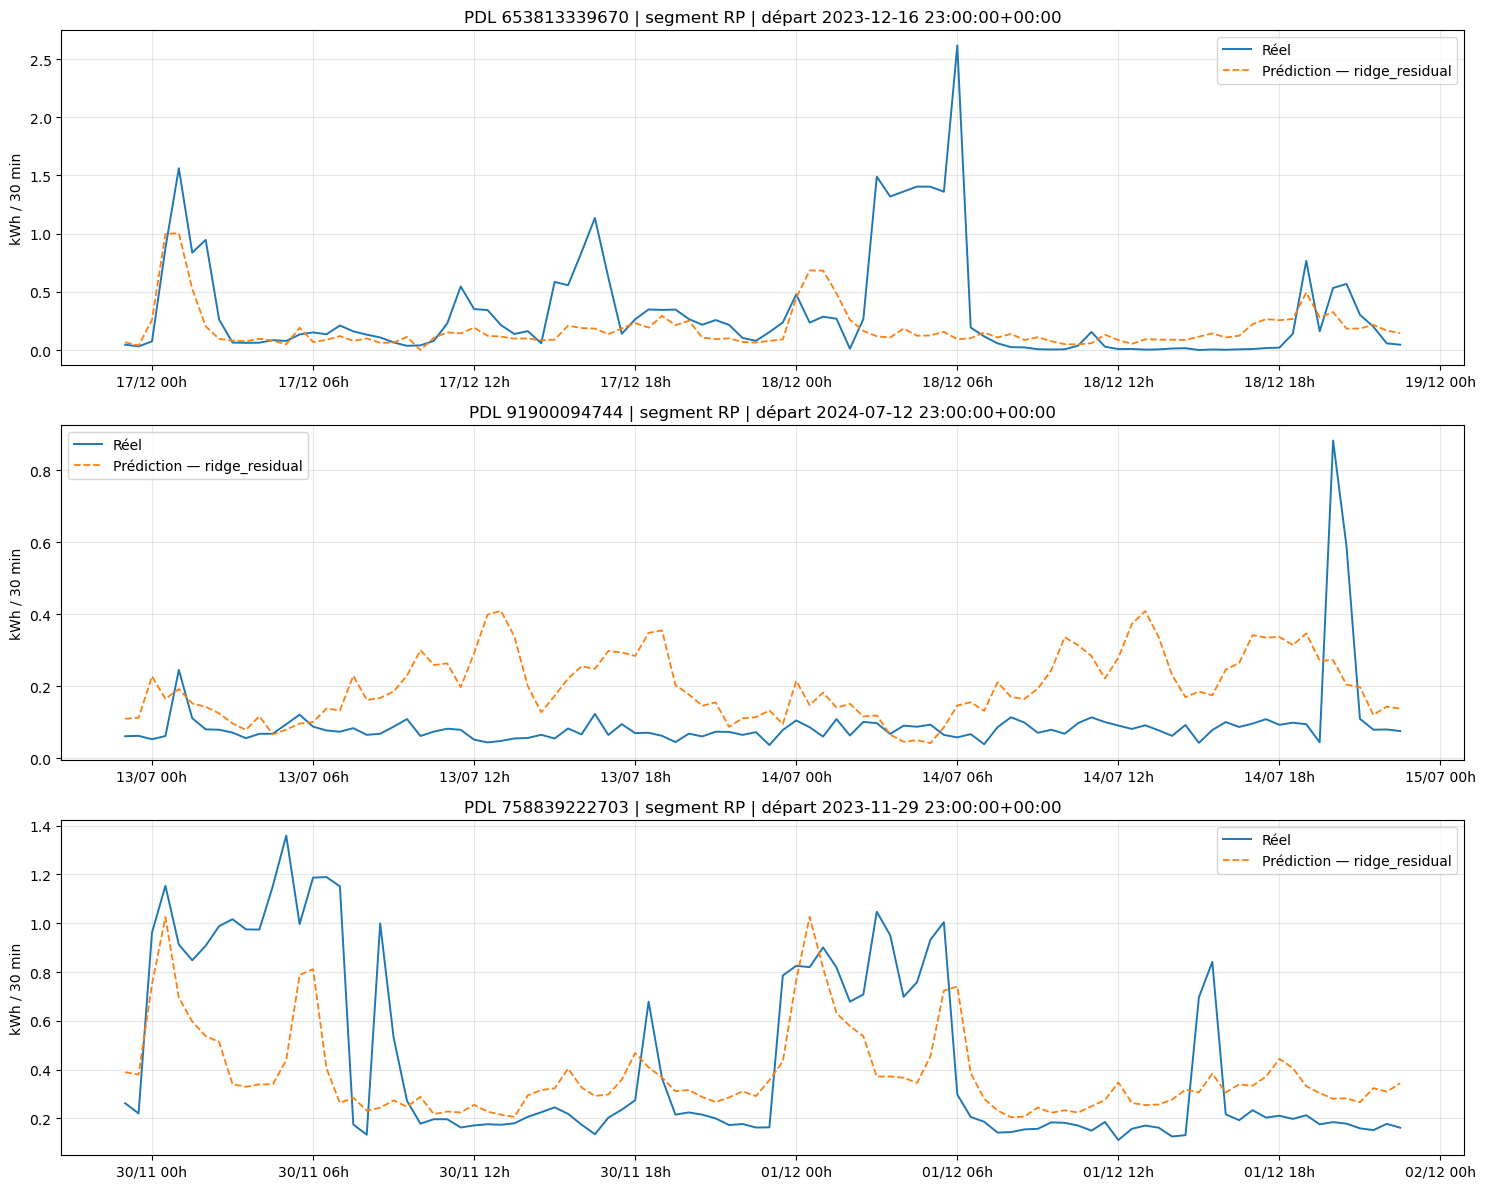

In [18]:
def get_prediction_array(model_name):
    if model_name == "baseline_recent":
        return B_recent
    if model_name == "baseline_weekly":
        return B_weekly
    if model_name == "ridge_residual":
        full_pred = np.empty_like(Y)
        full_pred[:] = np.nan
        # On calcule seulement pour validation + test afin d'éviter de stocker inutilement pour tout le train.
        for idx_part in [idx_val, idx_test]:
            pred_res = ridge_model.predict(X_tab[idx_part]).astype(np.float32)
            full_pred[idx_part] = np.clip(B_base[idx_part] + pred_res, 0, None)
        return full_pred
    if model_name == "cnn_residual" and pred_cnn_test is not None:
        full_pred = np.empty_like(Y)
        full_pred[:] = np.nan
        full_pred[idx_test] = pred_cnn_test
        return full_pred
    return B_weekly

# On visualise le meilleur modèle ALL selon validation, si disponible.
model_to_plot = best_by_val.get("ALL", "baseline_weekly")
Y_pred_plot = get_prediction_array(model_to_plot)

rng = np.random.default_rng(RANDOM_STATE)
plot_indices = rng.choice(idx_test, size=min(3, len(idx_test)), replace=False)

fig, axes = plt.subplots(len(plot_indices), 1, figsize=(15, 4 * len(plot_indices)))
if len(plot_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, plot_indices):
    start_time = forecast_starts.iloc[idx]
    dates = pd.date_range(start=start_time, periods=HORIZON, freq="30min")
    ax.plot(dates, Y[idx], label="Réel", linewidth=1.4)
    ax.plot(dates, Y_pred_plot[idx], label=f"Prédiction — {model_to_plot}", linewidth=1.3, linestyle="--")
    ax.set_title(f"PDL {windows.iloc[idx]['pdl_id']} | segment {windows.iloc[idx]['segment']} | départ {start_time}")
    ax.set_ylabel("kWh / 30 min")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh"))
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()



## 10. Fonction de prédiction pour un client donné

La fonction ci-dessous prend un `pdl_id`, récupère ses 14 derniers jours observés, et renvoie la prédiction des 2 jours suivants avec le modèle choisi.

In [19]:
def predict_next_2_days_for_client(pdl_id, model_name=None):
    if model_name is None:
        model_name = best_by_val.get("ALL", "baseline_weekly")

    g = raw[raw["pdl_id"] == pdl_id].sort_values("horodate")
    if len(g) < INPUT_LEN:
        raise ValueError(f"Historique insuffisant pour le client {pdl_id}.")

    segment = g["segment"].iloc[-1]
    values = g["kwh"].to_numpy(dtype=np.float32)
    times = g["horodate"].to_numpy()

    past_seq = values[-INPUT_LEN:]
    anchor_time = pd.Timestamp(times[-1])
    forecast_start = anchor_time + pd.Timedelta(minutes=30)
    future_dates = pd.date_range(start=forecast_start, periods=HORIZON, freq="30min")

    extra = build_extra_features(past_seq, anchor_time, segment).reshape(1, -1)
    x_seq_one = past_seq.reshape(1, -1)
    x_tab_one = np.hstack([x_seq_one, extra]).astype(np.float32)

    b_recent = past_seq[-HORIZON:].reshape(1, -1)
    b_weekly = past_seq[INPUT_LEN - 336:INPUT_LEN - 336 + HORIZON].reshape(1, -1)
    b_base_one = b_recent if BASELINE_MODEL == "baseline_recent" else b_weekly

    if model_name == "baseline_recent":
        pred = b_recent[0]
    elif model_name == "baseline_weekly":
        pred = b_weekly[0]
    elif model_name == "ridge_residual":
        pred_res = ridge_model.predict(x_tab_one).astype(np.float32)
        pred = np.clip(b_base_one + pred_res, 0, None)[0]
    elif model_name == "cnn_residual" and cnn_model is not None:
        x_seq_scaled = (x_seq_one / seq_scale).astype(np.float32)
        x_extra_scaled = ((extra - extra_mean) / extra_std).astype(np.float32)
        cnn_model.eval()
        with torch.no_grad():
            xb_seq = torch.from_numpy(x_seq_scaled).to(DEVICE)
            xb_extra = torch.from_numpy(x_extra_scaled).to(DEVICE)
            pred_res = cnn_model(xb_seq, xb_extra).cpu().numpy() * seq_scale
        pred = np.clip(b_base_one + pred_res, 0, None)[0]
    else:
        raise ValueError(f"Modèle inconnu ou non disponible : {model_name}")

    out = pd.DataFrame({
        "horodate": future_dates,
        "prediction_kwh": pred,
        "pdl_id": pdl_id,
        "segment": segment,
        "modele": model_name,
    })
    return out

# Exemple d'utilisation avec le premier client disponible
example_pdl = raw["pdl_id"].iloc[0]
forecast_example = predict_next_2_days_for_client(example_pdl)
print(f"Exemple de prédiction pour le client {example_pdl}")
display(forecast_example.head())



Exemple de prédiction pour le client 1704875583


,horodate,prediction_kwh,pdl_id,segment,modele
0,2024-10-29 23:00:00+00:00,0.236455,1704875583,RP,ridge_residual
1,2024-10-29 23:30:00+00:00,0.216321,1704875583,RP,ridge_residual
2,2024-10-30 00:00:00+00:00,0.177706,1704875583,RP,ridge_residual
3,2024-10-30 00:30:00+00:00,0.185606,1704875583,RP,ridge_residual
4,2024-10-30 01:00:00+00:00,0.203691,1704875583,RP,ridge_residual


Analyse de l'importance des variables du Ridge résiduel
Nombre de variables nommées : 732
Nombre de variables dans X_tab : 732
Forme des coefficients Ridge : (96, 732)
Top 30 des variables les plus importantes :


,feature,importance
691,std_1d,0.026117
685,lag_1,0.016872
671,conso_passee_t-1,0.016872
667,conso_passee_t-5,0.016573
623,conso_passee_t-49,0.013793
731,diff_mean_1d_7d,0.013572
668,conso_passee_t-4,0.012981
665,conso_passee_t-7,0.012869
669,conso_passee_t-3,0.012682
670,conso_passee_t-2,0.012644


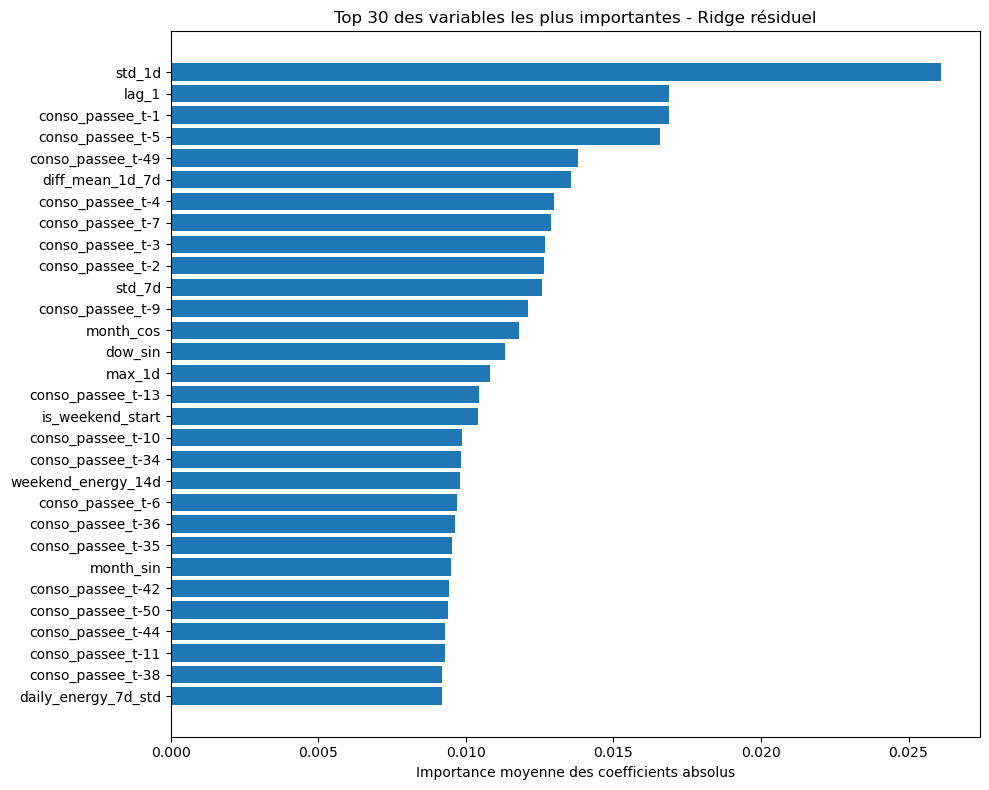

Importance des variables par famille :


,famille,importance
2,Courbe passée,1.942970
5,Statistiques,0.134760
1,Calendrier,0.078689
0,Activité passée,0.034978
3,Lags,0.026309
4,RP / RS,0.000939


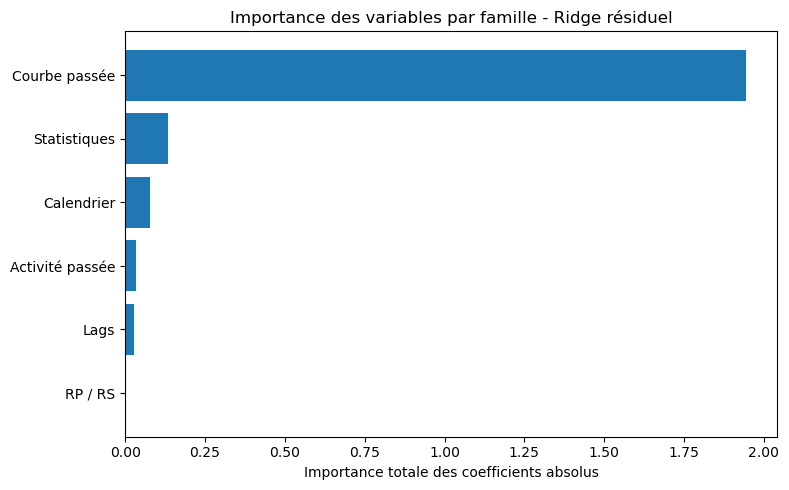

In [21]:
# ============================================================
# Analyse de l'importance des variables du Ridge résiduel
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Analyse de l'importance des variables du Ridge résiduel")

# ------------------------------------------------------------
# 1. Vérifications
# ------------------------------------------------------------

assert "ridge_model" in globals(), "Le modèle ridge_model n'existe pas. Exécute d'abord l'entraînement du Ridge."
assert "INPUT_LEN" in globals(), "La variable INPUT_LEN n'existe pas."
assert "X_extra" in globals(), "La variable X_extra n'existe pas."
assert "X_tab" in globals(), "La variable X_tab n'existe pas."

# ------------------------------------------------------------
# 2. Reconstruction des noms de variables
# ------------------------------------------------------------

seq_feature_names = [f"conso_passee_t-{INPUT_LEN - i}" for i in range(INPUT_LEN)]

if "EXTRA_FEATURE_NAMES" in globals():
    extra_names = list(EXTRA_FEATURE_NAMES)
else:
    extra_names = [f"feature_extra_{i}" for i in range(X_extra.shape[1])]

all_feature_names = seq_feature_names + extra_names

print("Nombre de variables nommées :", len(all_feature_names))
print("Nombre de variables dans X_tab :", X_tab.shape[1])

if len(all_feature_names) != X_tab.shape[1]:
    print("Attention : le nombre de noms ne correspond pas exactement au nombre de variables.")
    all_feature_names = [f"feature_{i}" for i in range(X_tab.shape[1])]

# ------------------------------------------------------------
# 3. Récupération des coefficients du Ridge
# ------------------------------------------------------------

# ridge_model est un Pipeline : StandardScaler + Ridge.
# Il faut donc récupérer le modèle Ridge à l'intérieur du pipeline.
if hasattr(ridge_model, "named_steps"):
    ridge_estimator = ridge_model.named_steps["ridge"]
else:
    ridge_estimator = ridge_model

coef = ridge_estimator.coef_

print("Forme des coefficients Ridge :", coef.shape)

# Le Ridge prédit 96 valeurs.
# coef a donc normalement la forme : (96, nombre_de_variables)
# On calcule une importance globale par variable :
# importance = moyenne des valeurs absolues des coefficients sur les 96 sorties.

if coef.ndim == 2:
    importance = np.mean(np.abs(coef), axis=0)
else:
    importance = np.abs(coef)

importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importance
}).sort_values("importance", ascending=False)

print("Top 30 des variables les plus importantes :")
display(importance_df.head(30))

# ------------------------------------------------------------
# 4. Graphique des 30 variables les plus importantes
# ------------------------------------------------------------

top_n = 30
top_features = importance_df.head(top_n).copy()

plt.figure(figsize=(10, 8))
plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)
plt.xlabel("Importance moyenne des coefficients absolus")
plt.title("Top 30 des variables les plus importantes - Ridge résiduel")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Regroupement des variables par famille
# ------------------------------------------------------------

def feature_group(name):
    if name.startswith("conso_passee"):
        return "Courbe passée"

    elif name.startswith("lag"):
        return "Lags"

    elif name in ["is_RS", "is_RP"]:
        return "RP / RS"

    elif (
        "season" in name
        or "month" in name
        or "dow" in name
        or "weekend" in name
        or "holiday" in name
    ):
        return "Calendrier"

    elif "active" in name:
        return "Activité passée"

    elif (
        "mean" in name
        or "std" in name
        or "min" in name
        or "max" in name
        or "sum" in name
        or "energy" in name
    ):
        return "Statistiques"

    elif "ratio" in name or "diff" in name:
        return "Tendances"

    else:
        return "Autres"

importance_df["famille"] = importance_df["feature"].apply(feature_group)

group_importance = (
    importance_df
    .groupby("famille", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

print("Importance des variables par famille :")
display(group_importance)

plt.figure(figsize=(8, 5))
plt.barh(
    group_importance["famille"][::-1],
    group_importance["importance"][::-1]
)
plt.xlabel("Importance totale des coefficients absolus")
plt.title("Importance des variables par famille - Ridge résiduel")
plt.tight_layout()
plt.show()
